In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv("/content/drive/MyDrive/project/healthcare_dataset.csv")

In [7]:
df.columns

Index(['Patient_ID', 'Gender', 'Age', 'Medical_Condition', 'Admission_Date',
       'Admission_Type', 'Medical_Code', 'Billing_Amount', 'Discharge_Date'],
      dtype='object')

In [8]:
df.isnull()

,Patient_ID,Gender,Age,Medical_Condition,Admission_Date,Admission_Type,Medical_Code,Billing_Amount,Discharge_Date
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
495,False,False,False,False,False,False,False,False,False
496,False,False,False,False,False,False,False,False,False
497,False,False,False,False,False,False,False,False,False
498,False,False,False,False,False,False,False,False,False


In [9]:
df.isnull().sum()

,0
Patient_ID,0
Gender,0
Age,0
Medical_Condition,0
Admission_Date,0
Admission_Type,0
Medical_Code,15
Billing_Amount,0
Discharge_Date,0


In [13]:
df['Admission_Date']=pd.to_datetime(df['Admission_Date'], dayfirst=True)
df['Discharge_Date']=pd.to_datetime(df['Discharge_Date'], dayfirst=True)

In [14]:
df["No_of_days_stay"]=df["Discharge_Date"]-df["Admission_Date"]

In [15]:
df['No_of_days_stay'].head()

,No_of_days_stay
0,5 days
1,6 days
2,2 days
3,2 days
4,8 days


In [25]:
billing=df.groupby(['Medical_Condition'])['Billing_Amount'].sum()
billing

,Billing_Amount
Medical_Condition,
Allergic Reaction,58800.0
Anxiety Disorder,27800.0
Appendicitis,319400.0
Asthma,97900.0
Back Pain,76800.0
COPD,296200.0
Diabetes Type 1,72300.0
Diabetes Type 2,66200.0
Fracture,188500.0


<Axes: xlabel='Medical_Condition'>

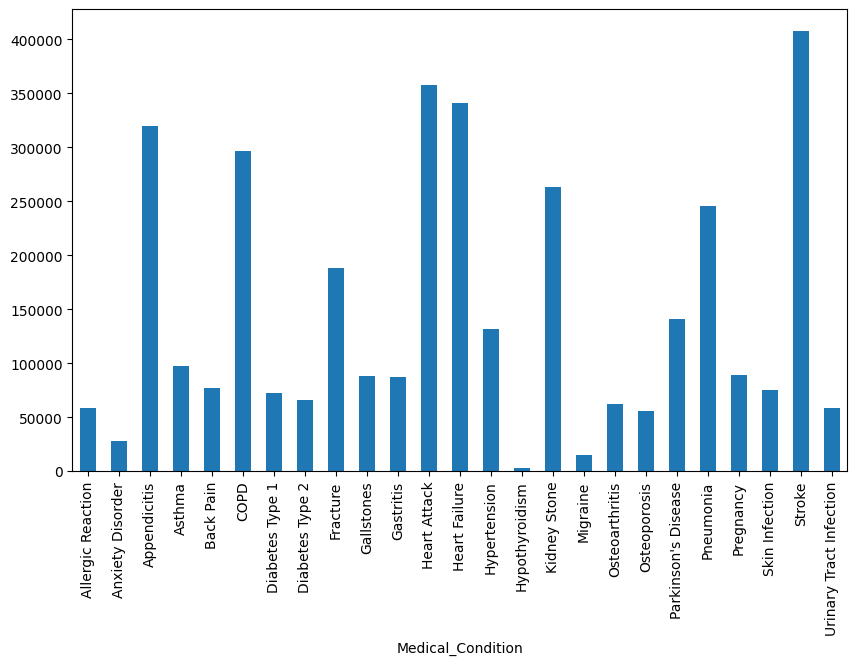

In [26]:
billing.plot(kind='bar',figsize=(10,6), stacked=True)

<Axes: xlabel='Medical_Condition', ylabel='Billing_Amount'>

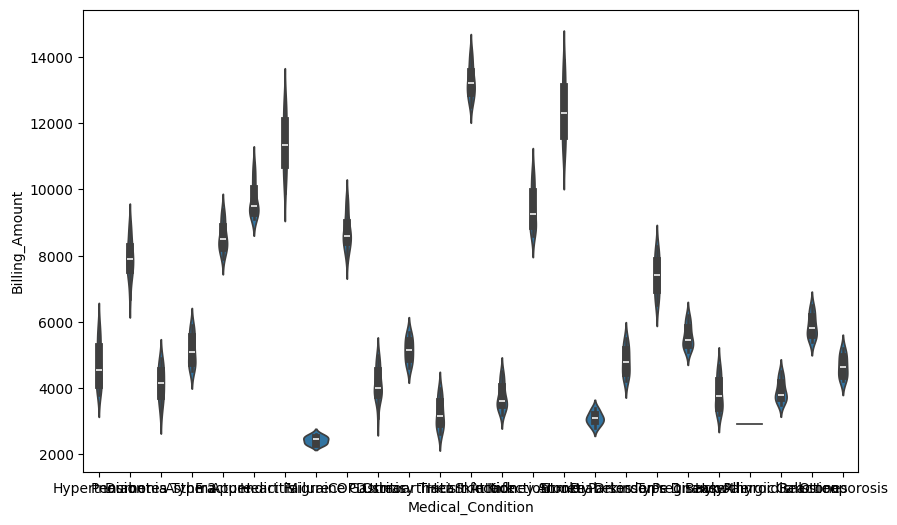

In [28]:
plt.figure(figsize=(10,6))
sns.violinplot(data=df,
               x='Medical_Condition',
               y='Billing_Amount')

<Axes: xlabel='Admission_Type', ylabel='Billing_Amount'>

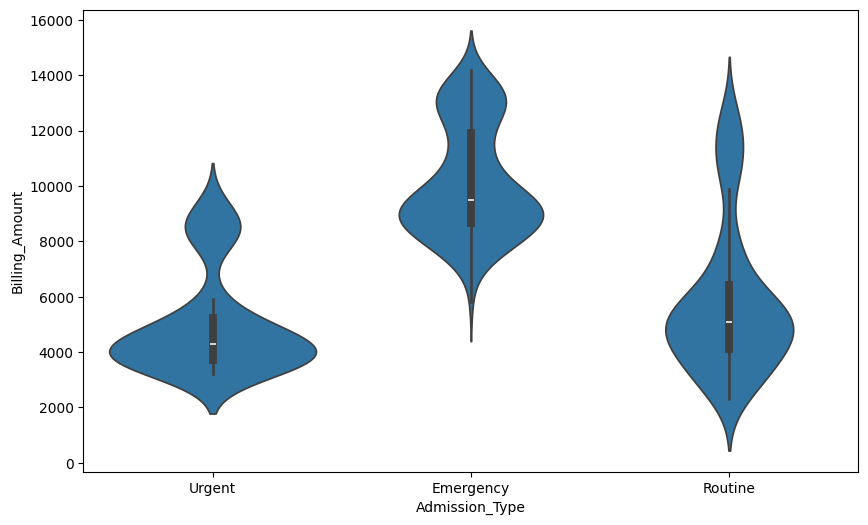

In [30]:
plt.figure(figsize=(10,6))
sns.violinplot(data=df,
               x='Admission_Type',
               y='Billing_Amount')

In [32]:
df['Admission Month']=df['Admission_Date'].dt.month
df['Admission Month']

,Admission Month
0,1
1,1
2,1
3,1
4,1
...,...
495,9
496,9
497,9
498,9


In [33]:
monthly_sub=df.groupby('Admission Month').size()
monthly_sub

,0
Admission Month,
1,33
2,56
3,62
4,60
5,62
6,60
7,62
8,62
9,43


<Axes: xlabel='Admission Month'>

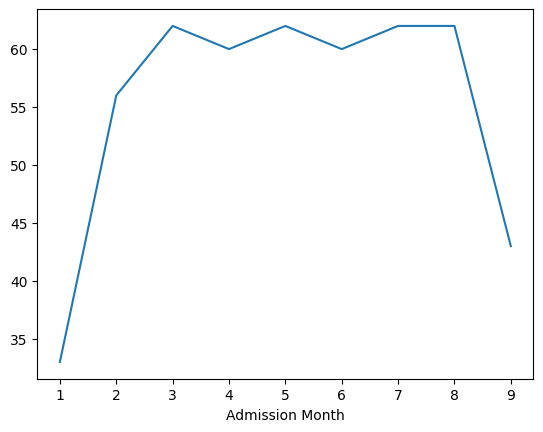

In [34]:
monthly_sub.plot()

In [36]:
Corr_matrix=df[['Age','No_of_days_stay', 'Billing_Amount']].corr()
Corr_matrix

,Age,No_of_days_stay,Billing_Amount
Age,1.000000,0.532377,0.455645
No_of_days_stay,0.532377,1.000000,0.652968
Billing_Amount,0.455645,0.652968,1.000000


<Axes: >

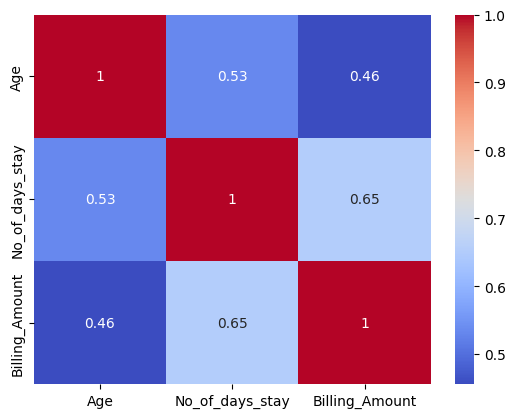

In [37]:
sns.heatmap(Corr_matrix, annot=True, cmap="coolwarm")